# Dimension Reduction Code

## Importing Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as skl
from ISLP.models import ModelSpec
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Functions to be used in this notebook

In [ ]:
class PCARegression:
    def __init():

## Loading Data

In [5]:
pharmaceutical_df = pd.read_csv(os.path.join(os.getcwd(), 'generated_data', 'full_pharmaceutical_data.csv'))
pharmaceutical_df

,tender_id,translated_procedure_types,lot_productCode,tender_finalprice,tender_biddeadline,tender_contractsignaturedate,bidder_city,tender_year,quantity,unit_price,inflation_adj_unit_price,log_unit_price,num_tender_items,submission_period_days,tender_month,buyer_annual_total,tender_recordedbidscount,supplier_market_share
0,002e70ec-1a15-447b-8d17-c6ccb484b10f,Direct Hiring,25172504-002,6.321243e+07,2021-03-16,2021-04-19,San Lorenzo,2011,5.0,112700.00,214.94,5.37,10,9.0,3,4.995528e+07,1,5.752000e+06
1,002e70ec-1a15-447b-8d17-c6ccb484b10f,Direct Hiring,25172504-002,6.321243e+07,2021-03-16,2021-04-19,ASUNCION,2011,5.0,112700.00,214.94,5.37,10,9.0,3,4.995528e+07,1,4.420328e+07
2,00d5c9db-ca9e-4d2d-897c-4aead4521e4e,Offer Contest,44103105-002,1.215658e+08,2022-04-12,2022-11-22,ASUNCION (DISTRITO),2012,60.0,2250.68,4.29,1.46,4,29.0,3,3.646974e+08,1,1.155104e+09
3,00d5c9db-ca9e-4d2d-897c-4aead4521e4e,Offer Contest,44103103-001,1.215658e+08,2022-04-12,2022-11-22,ASUNCION (DISTRITO),2012,50.0,18602.32,35.46,3.57,4,29.0,3,3.646974e+08,1,1.155104e+09
4,00d5c9db-ca9e-4d2d-897c-4aead4521e4e,Offer Contest,44103105-001,1.215658e+08,2022-04-12,2022-11-22,ASUNCION (DISTRITO),2012,5.0,41771.60,79.63,4.38,4,29.0,3,3.646974e+08,1,1.155104e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,954e5180-2081-48d8-8215-29f86c5b9370,Direct Hiring,44122107-001,5.662655e+06,2021-06-15,2021-10-20,ASUNCION,2011,1.0,5000.00,9.54,2.26,87,29.0,5,8.633980e+06,1,5.974100e+06
355,954e5180-2081-48d8-8215-29f86c5b9370,Direct Hiring,44121905-001,5.662655e+06,2021-06-15,2021-10-20,ASUNCION,2011,1.0,1500.00,2.86,1.05,87,29.0,5,8.633980e+06,1,5.974100e+06
356,95f240d9-6041-4914-952e-4c81fbd58c75,National Public Tender,25172504-002,1.437000e+09,2024-08-07,2024-09-16,ASUNCION (DISTRITO),2014,40.0,14850.00,28.28,3.34,34,29.0,7,1.437000e+09,8,6.475800e+08
357,95f240d9-6041-4914-952e-4c81fbd58c75,National Public Tender,25172504-002,1.437000e+09,2024-08-07,2024-09-16,ASUNCIÓN.,2014,40.0,14850.00,28.28,3.34,34,29.0,7,1.437000e+09,9,8.000000e+08


In [6]:
pharmaceutical_df['tender_contractsignaturedate'] = pd.to_datetime(pharmaceutical_df['tender_contractsignaturedate'])
pharmaceutical_df['tender_biddeadline'] = pd.to_datetime(pharmaceutical_df['tender_biddeadline'])
# contract_signature_days = pharmaceutical_df['tender_contractsignaturedate'] - pharmaceutical_df['tender_biddeadline']

In [7]:
# pharmaceutical_df['contract_signed_days'] = contract_signature_days.dt.days
pharmaceutical_df

,tender_id,translated_procedure_types,lot_productCode,tender_finalprice,tender_biddeadline,tender_contractsignaturedate,bidder_city,tender_year,quantity,unit_price,inflation_adj_unit_price,log_unit_price,num_tender_items,submission_period_days,tender_month,buyer_annual_total,tender_recordedbidscount,supplier_market_share
0,002e70ec-1a15-447b-8d17-c6ccb484b10f,Direct Hiring,25172504-002,6.321243e+07,2021-03-16,2021-04-19,San Lorenzo,2011,5.0,112700.00,214.94,5.37,10,9.0,3,4.995528e+07,1,5.752000e+06
1,002e70ec-1a15-447b-8d17-c6ccb484b10f,Direct Hiring,25172504-002,6.321243e+07,2021-03-16,2021-04-19,ASUNCION,2011,5.0,112700.00,214.94,5.37,10,9.0,3,4.995528e+07,1,4.420328e+07
2,00d5c9db-ca9e-4d2d-897c-4aead4521e4e,Offer Contest,44103105-002,1.215658e+08,2022-04-12,2022-11-22,ASUNCION (DISTRITO),2012,60.0,2250.68,4.29,1.46,4,29.0,3,3.646974e+08,1,1.155104e+09
3,00d5c9db-ca9e-4d2d-897c-4aead4521e4e,Offer Contest,44103103-001,1.215658e+08,2022-04-12,2022-11-22,ASUNCION (DISTRITO),2012,50.0,18602.32,35.46,3.57,4,29.0,3,3.646974e+08,1,1.155104e+09
4,00d5c9db-ca9e-4d2d-897c-4aead4521e4e,Offer Contest,44103105-001,1.215658e+08,2022-04-12,2022-11-22,ASUNCION (DISTRITO),2012,5.0,41771.60,79.63,4.38,4,29.0,3,3.646974e+08,1,1.155104e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,954e5180-2081-48d8-8215-29f86c5b9370,Direct Hiring,44122107-001,5.662655e+06,2021-06-15,2021-10-20,ASUNCION,2011,1.0,5000.00,9.54,2.26,87,29.0,5,8.633980e+06,1,5.974100e+06
355,954e5180-2081-48d8-8215-29f86c5b9370,Direct Hiring,44121905-001,5.662655e+06,2021-06-15,2021-10-20,ASUNCION,2011,1.0,1500.00,2.86,1.05,87,29.0,5,8.633980e+06,1,5.974100e+06
356,95f240d9-6041-4914-952e-4c81fbd58c75,National Public Tender,25172504-002,1.437000e+09,2024-08-07,2024-09-16,ASUNCION (DISTRITO),2014,40.0,14850.00,28.28,3.34,34,29.0,7,1.437000e+09,8,6.475800e+08
357,95f240d9-6041-4914-952e-4c81fbd58c75,National Public Tender,25172504-002,1.437000e+09,2024-08-07,2024-09-16,ASUNCIÓN.,2014,40.0,14850.00,28.28,3.34,34,29.0,7,1.437000e+09,9,8.000000e+08


## Preprocessing Numeric Variables

In [8]:
pharmaceutical_df.dtypes

tender_id                               object
translated_procedure_types              object
lot_productCode                         object
tender_finalprice                      float64
tender_biddeadline              datetime64[ns]
tender_contractsignaturedate    datetime64[ns]
bidder_city                             object
tender_year                              int64
quantity                               float64
unit_price                             float64
inflation_adj_unit_price               float64
log_unit_price                         float64
num_tender_items                         int64
submission_period_days                 float64
tender_month                             int64
buyer_annual_total                     float64
tender_recordedbidscount                 int64
supplier_market_share                  float64
dtype: object

Creating a numeric df for standardising the values

In [9]:
numeric_df = pharmaceutical_df.drop(columns = ['tender_id', 
                                               'translated_procedure_types', 
                                               'lot_productCode', 
                                               'tender_biddeadline', 
                                               'tender_contractsignaturedate', 
                                               'bidder_city', 
                                               'unit_price',
                                               'inflation_adj_unit_price'])
numeric_df

,tender_finalprice,tender_year,quantity,log_unit_price,num_tender_items,submission_period_days,tender_month,buyer_annual_total,tender_recordedbidscount,supplier_market_share
0,6.321243e+07,2011,5.0,5.37,10,9.0,3,4.995528e+07,1,5.752000e+06
1,6.321243e+07,2011,5.0,5.37,10,9.0,3,4.995528e+07,1,4.420328e+07
2,1.215658e+08,2012,60.0,1.46,4,29.0,3,3.646974e+08,1,1.155104e+09
3,1.215658e+08,2012,50.0,3.57,4,29.0,3,3.646974e+08,1,1.155104e+09
4,1.215658e+08,2012,5.0,4.38,4,29.0,3,3.646974e+08,1,1.155104e+09
...,...,...,...,...,...,...,...,...,...,...
354,5.662655e+06,2011,1.0,2.26,87,29.0,5,8.633980e+06,1,5.974100e+06
355,5.662655e+06,2011,1.0,1.05,87,29.0,5,8.633980e+06,1,5.974100e+06
356,1.437000e+09,2014,40.0,3.34,34,29.0,7,1.437000e+09,8,6.475800e+08
357,1.437000e+09,2014,40.0,3.34,34,29.0,7,1.437000e+09,9,8.000000e+08


Then applying the `StandardScaler` to these variables

In [10]:
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns = numeric_df.columns)
numeric_scaled_df

,tender_finalprice,tender_year,quantity,log_unit_price,num_tender_items,submission_period_days,tender_month,buyer_annual_total,tender_recordedbidscount,supplier_market_share
0,-0.089033,-0.920664,-0.249188,0.681911,-0.544847,-0.913807,-0.624303,-0.282345,-0.685973,-0.457569
1,-0.089033,-0.920664,-0.249188,0.681911,-0.544847,-0.913807,-0.624303,-0.282345,-0.685973,-0.426430
2,-0.083797,-0.585112,1.037479,-1.377319,-0.692377,-0.436490,-0.624303,-0.018753,-0.685973,0.473228
3,-0.083797,-0.585112,0.803540,-0.266072,-0.692377,-0.436490,-0.624303,-0.018753,-0.685973,0.473228
4,-0.083797,-0.585112,-0.249188,0.160520,-0.692377,-0.436490,-0.624303,-0.018753,-0.685973,0.473228
...,...,...,...,...,...,...,...,...,...,...
354,-0.094197,-0.920664,-0.342764,-0.955993,1.348453,-0.436490,0.098680,-0.316951,-0.685973,-0.457389
355,-0.094197,-0.920664,-0.342764,-1.593249,1.348453,-0.436490,0.098680,-0.316951,-0.685973,-0.457389
356,0.034238,0.085991,0.569600,-0.387203,0.045273,-0.436490,0.821664,0.879286,1.142076,0.062212
357,0.034238,0.085991,0.569600,-0.387203,0.045273,-0.436490,0.821664,0.879286,1.403226,0.185649


Needing to drop NA values for Dimension Reduction to work. Then using train test split to be able to run the model

In [11]:
numeric_scaled_df = numeric_scaled_df.dropna()

X_train, X_test, Y_train, Y_test = train_test_split(numeric_scaled_df, 
                                                    numeric_scaled_df['log_unit_price'], 
                                                    test_size = 0.3, 
                                                    random_state = 42)

In [12]:
design = ModelSpec(numeric_scaled_df.columns.drop('log_unit_price')).fit(numeric_scaled_df)
X_train = design.transform(X_train)
X_test = design.transform(X_test)

## Training the Models Using PCA

### Applying A Standard Linear Regression

In [13]:
pca = PCA(n_components = 5)
linear_regression = skl.LinearRegression()
pipeline = Pipeline([
                        ('pca', pca),
                        ('linear_regression', linear_regression())
                     ]
                    )


pipeline.fit(X_train, Y_train)
pipeline.named_steps['linear_regression'].coef_

array([ 0.05551568, -0.15999476,  0.15852744, -0.17266154, -0.18746937])

#### Using GridSearchCV to optimise number of components

In [14]:
parameter_grid = {'pca__n_components' : range(1, 8)}

kfold_val = KFold(5, random_state = 42, shuffle = True)
grid = GridSearchCV(pipeline, parameter_grid, cv = kfold_val, scoring = 'neg_mean_squared_error')
grid.fit(X_train, Y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'pca__n_components': range(1, 8)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,5


#### Testing the Pipeline with the Optimised Pipeline

In [21]:
y_pred_log_optimised = grid.predict(X_test)

Text(0.5, 0, 'Number of Principal Components')

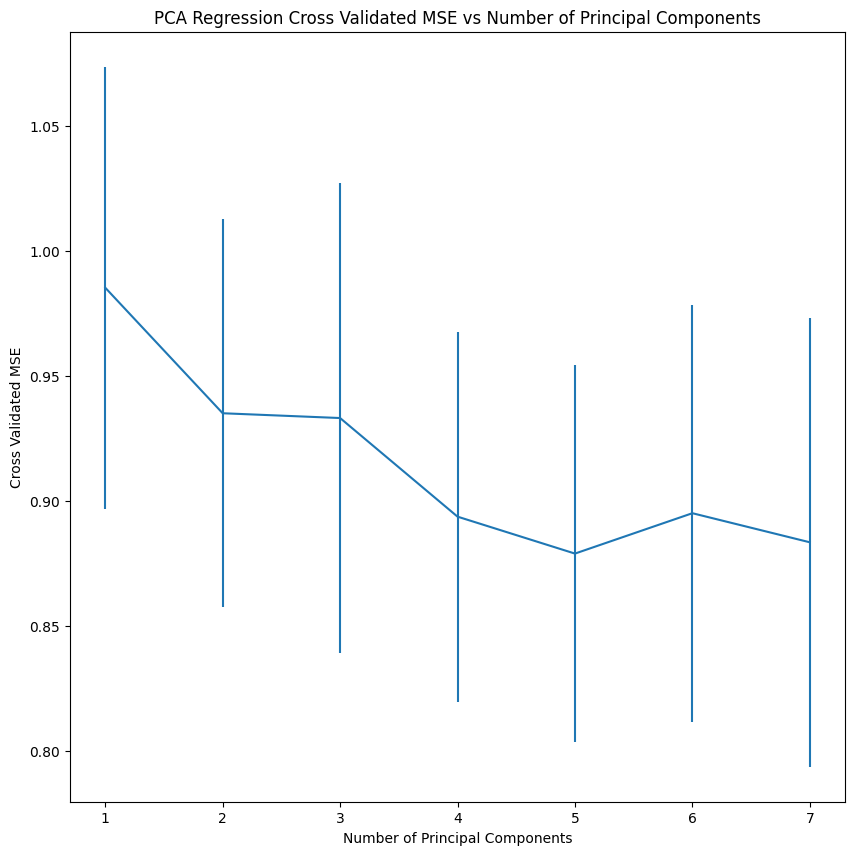

In [16]:
fig, ax = plt.subplots(figsize = (10, 10))

num_components = parameter_grid['pca__n_components']
ax.errorbar(num_components, 
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(5))

ax.set_title('PCA Regression Cross Validated MSE vs Number of Principal Components')
ax.set_ylabel('Cross Validated MSE')
ax.set_xlabel('Number of Principal Components')

In [17]:
pipeline.named_steps['pca'].explained_variance_ratio_

array([0.28409423, 0.18704935, 0.17164162, 0.11354847, 0.08873984])

### Applying a Ridge Regression in the Pipeline

## Computing the Metrics

In [19]:
r_2 = r2_score(Y_test, grid.predict(X_test))
mae = mean_absolute_error(Y_test, grid.predict(X_test))
rmse = np.sqrt(mean_squared_error(Y_test, grid.predict(X_test)))

print('R^2:', r_2)
print('MAE:', mae)
print('RMSE:', rmse)

R^2: 0.09087241466254692
MAE: 0.6803523408227298
RMSE: 0.9583033403804364
